<a href="https://colab.research.google.com/github/AngelohStout/BMEN-6367/blob/main/homework_2_Stout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/AngelohStout/BMEN-6367.git

Cloning into 'BMEN-6367'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [2]:
!ls BMEN-6367

'BMEN6367 Hw2.txt'


In [3]:
with open("BMEN-6367/BMEN6367 Hw2.txt", "r") as file:
    print(file.read())

hello world


Comments about Q3

I first loaded the image directly from my Google Drive using OpenCV. Since OpenCV reads images in BGR format, I converted the image to RGB so that the colors would display correctly with Matplotlib.

For the Gaussian filter, I used a sigma value of 2. This filter smooths the image by reducing small changes between neighboring pixels. From the result, the image became more blurred and some of the smaller details in the cat's fur and face were reduced.

I also applied a median filter with a size of 5. Instead of averaging the surrounding pixels, the median filter uses the median value of the neighboring pixels. The image became smoother, but it still kept more of the edges compared to the Gaussian filter.

For histogram equalization, I first converted the image to grayscale and then used equalizeHist(). The goal of this was to increase the contrast of the image by spreading the pixel intensity values across a wider range. After equalization, the darker and lighter areas of the image were more separated and some details were easier to see.

I also plotted the histogram before and after equalization. In the original image, more of the pixel values were grouped within certain intensity ranges. After histogram equalization, the values were spread across more of the 0–255 range, which explains the increase in contrast.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Image loaded successfully


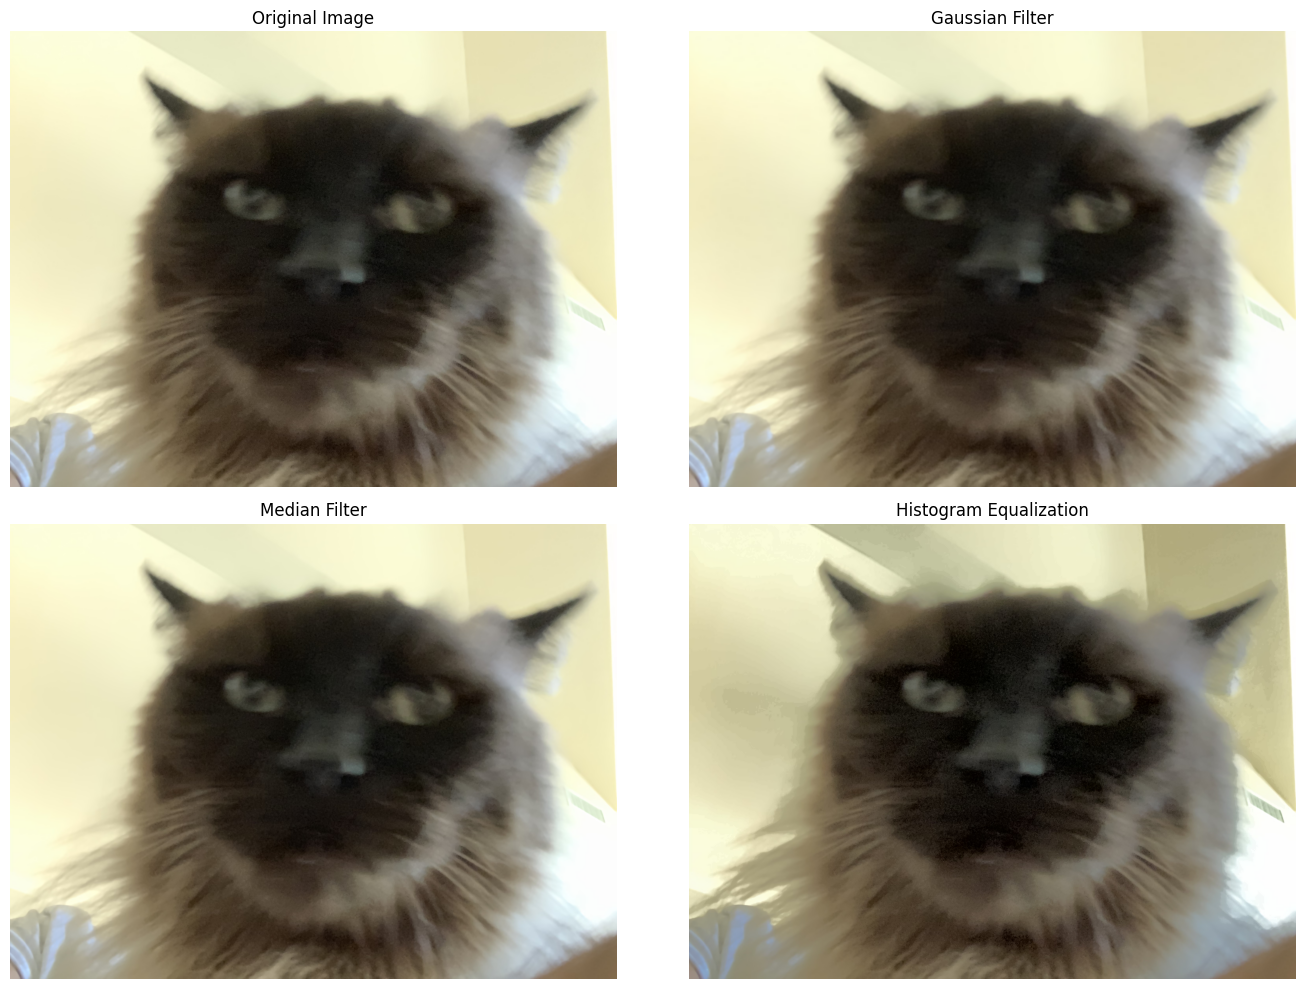

/tmp/ipykernel_1712/2067664253.py:91: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray_image.ravel(), 256, [0, 256])
/tmp/ipykernel_1712/2067664253.py:97: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized_image.ravel(), 256, [0, 256])


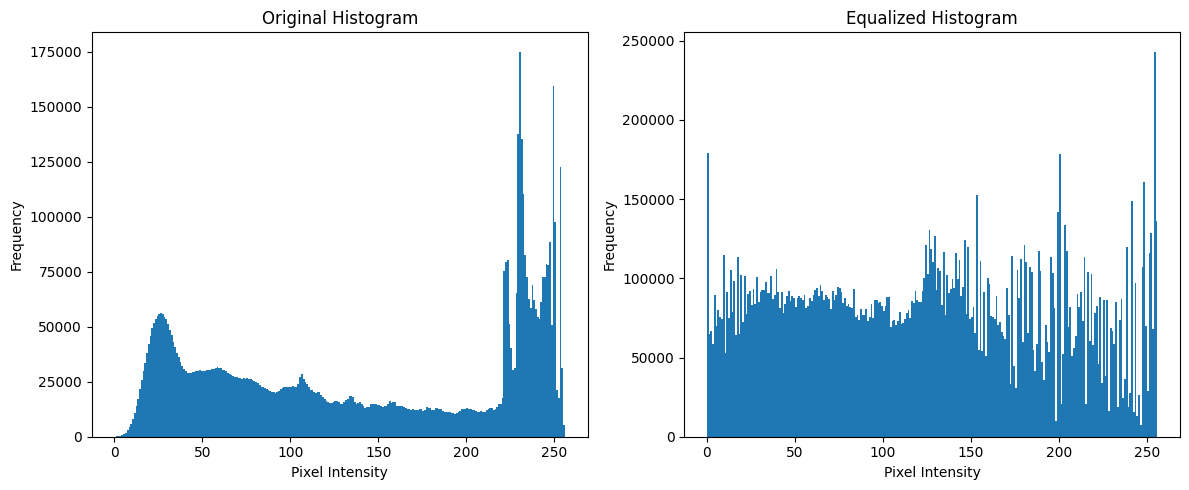

In [6]:
from google.colab import drive
drive.mount('/content/drive')

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, median_filter


# this is the source of where to read the picture of my cat
image_path = '/content/drive/MyDrive/BMEN6367/Pictures of my cat/IMG_0004.JPEG'
image = cv2.imread(image_path)

if image is None:
    print("Image could not be loaded")
else:
    print("Image loaded successfully")


# cv2 reads images as BGR so I changed it to RGB for matplotlib and overall filtering
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)



# Gaussian filter

# this smooths the image by averaging out some of the small changes in pixels
gaussian_image = np.zeros_like(image_rgb)

for channel in range(3):
    gaussian_image[:, :, channel] = gaussian_filter(image_rgb[:, :, channel],sigma=2)


# Median filter
# takes the median value of the pixels around each pixel
median_image = np.zeros_like(image_rgb)

for channel in range(3):
    median_image[:, :, channel] = median_filter(image_rgb[:, :, channel],size=5)


# Histogram equalization

# Histogram equalization while keeping the image in color

# convert BGR image to YCrCb
ycrcb_image = cv2.cvtColor(image, cv2.COLOR_BGR2YCrCb)

# equalize the brightness channel
ycrcb_image[:, :, 0] = cv2.equalizeHist(ycrcb_image[:, :, 0])

# convert back to RGB for matplotlib
equalized_image = cv2.cvtColor(ycrcb_image, cv2.COLOR_YCrCb2RGB)


# show all of the images
plt.figure(figsize=(14, 10))

# original
plt.subplot(2, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

# gaussian
plt.subplot(2, 2, 2)
plt.imshow(gaussian_image)
plt.title("Gaussian Filter")
plt.axis("off")

#median
plt.subplot(2, 2, 3)
plt.imshow(median_image)
plt.title("Median Filter")
plt.axis("off")

#histogram
plt.subplot(2, 2, 4)
plt.imshow(equalized_image, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")

plt.tight_layout()
plt.show()


# compare the histogram before and after equalization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(gray_image.ravel(), 256, [0, 256])
plt.title("Original Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(equalized_image.ravel(), 256, [0, 256])
plt.title("Equalized Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Question 4 **DFS**

I created a 25-node graph with 5 different layers and started the DFS search at node A. The program keeps track of the nodes that have already been visited so it does not repeat them. DFS follows one branch as far as it can before going back and trying another branch. Because of this, it reaches the deeper nodes first before moving on to other parts of the graph. Because it goes through each layer first. This will technically recursively go through ABC as I made the search like that.

DFS order:
A B C D E F G H I J K L M N O P Q R S T U V W X Y 

Text(0.5, 1.0, 'DFS Graph')

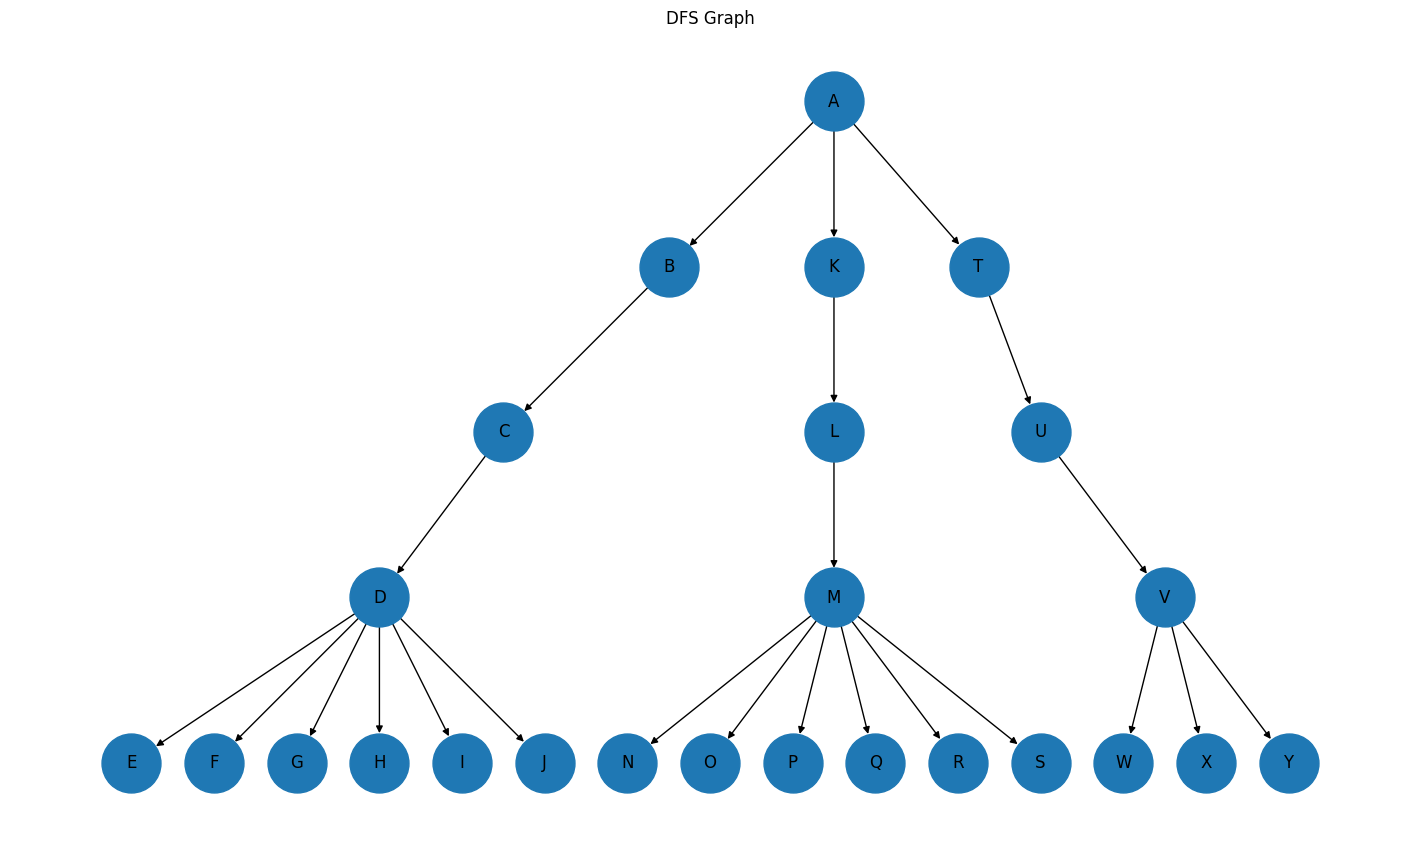

In [14]:
import networkx as nx
import matplotlib.pyplot as plt

# Using a Python dictionary to make the graph
graph = {
    'A': ['B', 'K', 'T'],

    'B': ['C'],
    'C': ['D'],
    'D': ['E', 'F', 'G', 'H', 'I', 'J'],

    'K': ['L'],
    'L': ['M'],
    'M': ['N', 'O', 'P', 'Q', 'R', 'S'],

    'T': ['U'],
    'U': ['V'],
    'V': ['W', 'X', 'Y'],

    'E': [],
    'F': [],
    'G': [],
    'H': [],
    'I': [],
    'J': [],

    'N': [],
    'O': [],
    'P': [],
    'Q': [],
    'R': [],
    'S': [],

    'W': [],
    'X': [],
    'Y': []
}

visited = [] # keeps track of visited nodes


def dfs(visited, graph, node):

    if node not in visited:
        print(node, end=" ")
        visited.append(node)

        for neighbour in graph[node]:
            dfs(visited, graph, neighbour)


# start at A
print("DFS order:")
dfs(visited, graph, 'A')


# create a directed graph
G = nx.DiGraph()

# add the nodes and connections from the dictionary
for node in graph:
    for neighbour in graph[node]:
        G.add_edge(node, neighbour)


# automatically arrange the graph like a tree
pos = nx.nx_pydot.graphviz_layout(G, prog="dot")


# display the graph
plt.figure(figsize=(14, 8))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1800,
    font_size=12,
    arrows=True
)

plt.title("DFS Graph")

# Q5. **BFS**

I used the same 25-node graph for BFS and also started at node A. Instead of following one path all the way down, BFS checks the graph one layer at a time. The nodes that still need to be visited are stored in a queue. Since the first node added to the queue is also the first one removed, the search follows a first-in, first-out order and finishes each level before moving to the next one.

BFS order:
A B C D E F G H I J K L M N O P Q R S T U V W X Y 

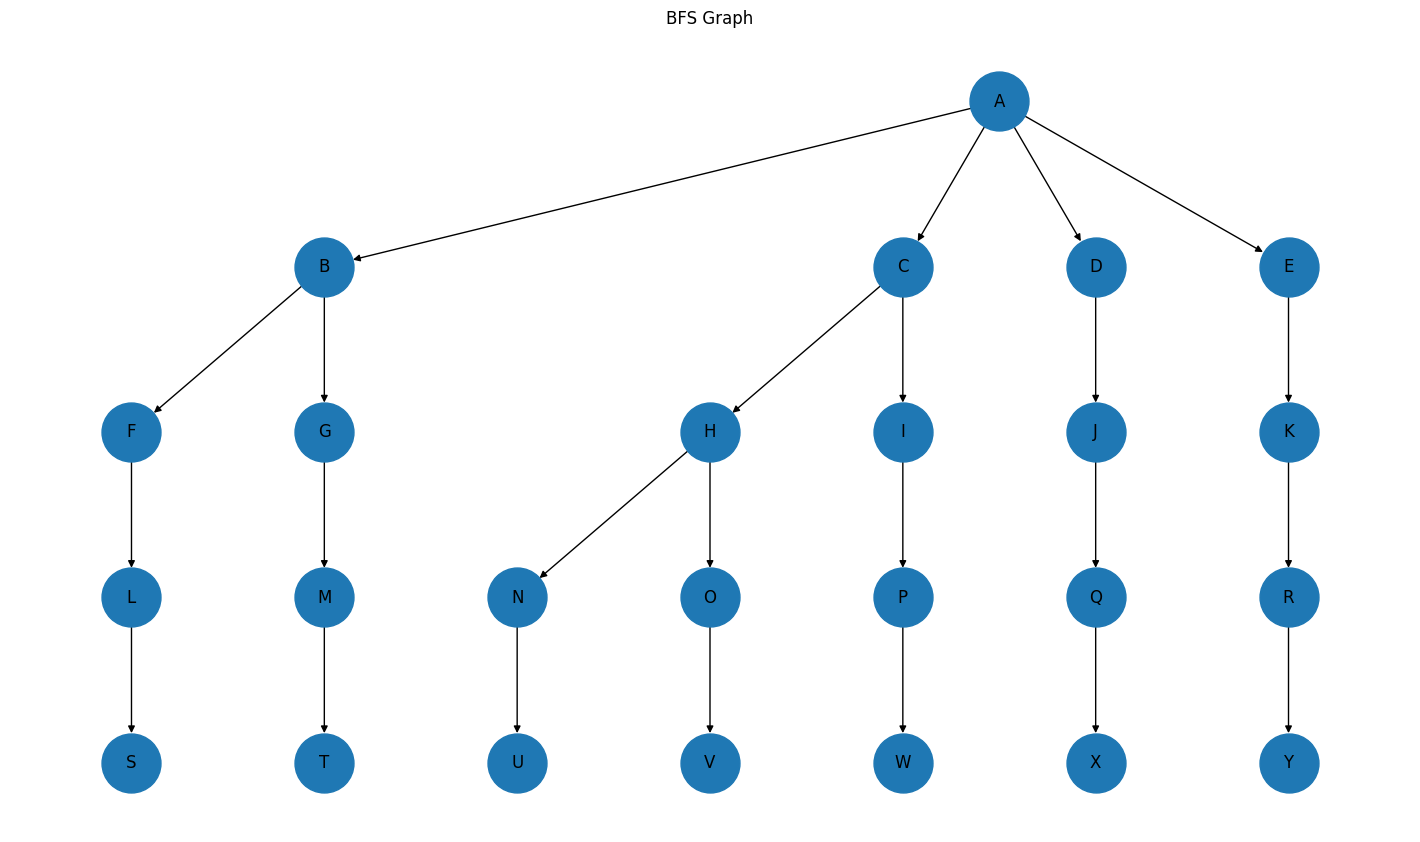

In [11]:
# Using a Python dictionary to make the graph
graph = {
    'A' : ['B', 'C', 'D', 'E'],

    'B' : ['F', 'G'],
    'C' : ['H', 'I'],
    'D' : ['J'],
    'E' : ['K'],

    'F' : ['L'],
    'G' : ['M'],
    'H' : ['N','O'],
    'I' : ['P'],
    'J' : ['Q'],
    'K' : ['R'],

    'L' : ['S'],
    'M' : ['T'],
    'N' : ['U'],
    'O' : ['V'],
    'P' : ['W'],
    'Q' : ['X'],
    'R' : ['Y'],

    'S' : [],
    'T' : [],
    'U' : [],
    'V' : [],
    'W' : [],
    'X' : [],
    'Y' : []
}

visited = [] # keeps track of visited nodes
queue = []   # queue for BFS

def bfs(visited, graph, node):
    visited.append(node)
    queue.append(node)

    while queue:
        s = queue.pop(0)
        print(s, end = " ")

        for neighbour in graph[s]:
            if neighbour not in visited:
                visited.append(neighbour)
                queue.append(neighbour)

# start at A
print("BFS order:")
bfs(visited, graph, 'A')

# create a directed graph
G = nx.DiGraph()

# add the nodes and connections from the dictionary
for node in graph:
    for neighbour in graph[node]:
        G.add_edge(node, neighbour)


# automatically arrange the graph like a tree
pos = nx.nx_pydot.graphviz_layout(G, prog="dot")


# display the graph
plt.figure(figsize=(14, 8))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1800,
    font_size=12,
    arrows=True
)

plt.title("BFS Graph")
plt.show()

DFS is useful when searching deeply through one possible path at a time, while BFS is useful when searching nearby nodes first or finding the shortest path in an unweighted graph.